# Logistic Regression: Predicting Customer Churn

This Notebook uses logistic regression to estimate the probability that a customer will cancel a subscription service.

# ロジスティック回帰：顧客のサービス解約を予測する

このNotebookでは、顧客属性とサービス利用状況から、顧客がサービスを解約する確率をロジスティック回帰で推定します。

## 1. Learning Objectives / 学習目標
- Understand binary logistic regression
- Understand probability, odds, log-odds, and the sigmoid function
- Build and evaluate a churn model
- Interpret coefficients and odds ratios
- Understand thresholds and ROC-AUC

- 2値ロジスティック回帰を理解する
- 確率・オッズ・対数オッズ・シグモイド関数を理解する
- 解約モデルを構築・評価する
- 係数とオッズ比を解釈する
- 閾値とROC-AUCを理解する

## 2. Use Case / ユースケース
A subscription service wants to identify customers who are likely to churn and use the result to consider retention measures.

サブスクリプションサービスで、解約する可能性が高い顧客を把握し、サポートや契約プラン見直しなどの施策検討に活用します。

## 3. Why Logistic Regression? / なぜロジスティック回帰なのか
The target `churn` is binary: `0 = Continue`, `1 = Churn`. Logistic regression models a probability between 0 and 1.

目的変数`churn`は`0=継続`、`1=解約`の2値です。ロジスティック回帰では0〜1の確率として予測できます。

## 4. Logistic Regression Model / モデルの考え方
First calculate a linear predictor:

`z = β0 + β1x1 + ... + βkxk`

Then convert it to a probability:

`p = 1 / (1 + exp(-z))`

Equivalently:

`log(p / (1-p)) = β0 + β1x1 + ... + βkxk`

Exponentiating a coefficient gives an **odds ratio**.

線形結合をシグモイド関数で0〜1の確率へ変換します。係数を指数変換すると**オッズ比**として解釈できます。

## 5. Import Libraries / ライブラリの読み込み

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
pd.set_option("display.max_columns", None)

## 6. Load the Dataset / データの読み込み

In [2]:
paths=[Path("../data/customer_churn.csv"),Path("06_logistic_regression/data/customer_churn.csv"),Path("data/customer_churn.csv")]
data_path=next((p for p in paths if p.exists()),None)
if data_path is None: raise FileNotFoundError("customer_churn.csv was not found.")
df=pd.read_csv(data_path)
df.head()

,customer_id,tenure_months,monthly_charge,support_tickets,login_frequency,days_since_last_login,satisfaction_score,auto_payment,contract_type,churn
0,C0001,71,108.19,0,7.8,6.2,4,1,Monthly,0
1,C0002,18,115.62,0,25.5,15.7,3,0,Two_Year,0
2,C0003,12,87.47,1,1.2,13.2,3,1,Annual,1
3,C0004,53,73.44,1,18.1,14.1,3,1,Monthly,0
4,C0005,23,35.97,1,8.6,7.1,3,1,Two_Year,0


## 7. Understand the Dataset / データの理解

In [3]:
print(f"Rows: {df.shape[0]}"); print(f"Columns: {df.shape[1]}"); df.info()

Rows: 300
Columns: 10
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            300 non-null    str    
 1   tenure_months          300 non-null    int64  
 2   monthly_charge         300 non-null    float64
 3   support_tickets        300 non-null    int64  
 4   login_frequency        300 non-null    float64
 5   days_since_last_login  300 non-null    float64
 6   satisfaction_score     300 non-null    int64  
 7   auto_payment           300 non-null    int64  
 8   contract_type          300 non-null    str    
 9   churn                  300 non-null    int64  
dtypes: float64(3), int64(5), str(2)
memory usage: 23.6 KB


In [4]:
df.isna().sum()

customer_id              0
tenure_months            0
monthly_charge           0
support_tickets          0
login_frequency          0
days_since_last_login    0
satisfaction_score       0
auto_payment             0
contract_type            0
churn                    0
dtype: int64

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,300,300,C0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,300.0,NaN,NaN,NaN,38.23,19.99976,1.0,22.0,38.5,55.0,72.0
monthly_charge,300.0,NaN,NaN,NaN,73.0792,22.83316,20.0,58.0925,72.98,89.6625,135.0
support_tickets,300.0,NaN,NaN,NaN,1.65,1.232571,0.0,1.0,2.0,2.0,6.0
login_frequency,300.0,NaN,NaN,NaN,13.539333,5.909585,1.0,9.4,13.5,17.275,30.0
days_since_last_login,300.0,NaN,NaN,NaN,11.782,7.840326,0.6,6.175,9.5,16.4,44.1
satisfaction_score,300.0,NaN,NaN,NaN,3.36,0.941642,1.0,3.0,3.0,4.0,5.0
auto_payment,300.0,NaN,NaN,NaN,0.586667,0.493254,0.0,0.0,1.0,1.0,1.0
contract_type,300,3,Monthly,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
churn,300.0,NaN,NaN,NaN,0.44,0.497216,0.0,0.0,0.0,1.0,1.0


churn
0    168
1    132
Name: count, dtype: int64
Churn rate: 0.440


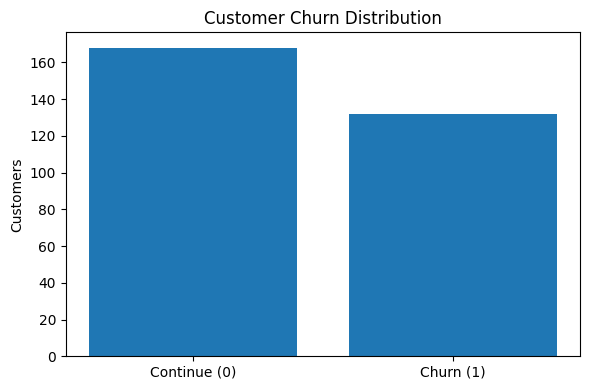

In [6]:
counts=df["churn"].value_counts().sort_index()
print(counts); print(f"Churn rate: {df['churn'].mean():.3f}")
plt.figure(figsize=(6,4)); plt.bar(["Continue (0)","Churn (1)"],counts.values)
plt.title("Customer Churn Distribution"); plt.ylabel("Customers"); plt.tight_layout(); plt.show()

## 8. Explore Churn Patterns / 解約傾向

In [7]:
numeric=["tenure_months","monthly_charge","support_tickets","login_frequency","days_since_last_login","satisfaction_score","auto_payment"]
df.groupby("churn")[numeric].mean().round(2)

,tenure_months,monthly_charge,support_tickets,login_frequency,days_since_last_login,satisfaction_score,auto_payment
churn,,,,,,,
0,43.70,70.64,1.43,14.2,10.55,3.55,0.66
1,31.27,76.18,1.93,12.7,13.35,3.12,0.49


In [8]:
pd.crosstab(df["contract_type"],df["churn"],normalize="index").round(3)

churn,0,1
contract_type,,
Annual,0.578,0.422
Monthly,0.494,0.506
Two_Year,0.722,0.278


## 9. Prepare the Data / 分析データの準備
`customer_id` is excluded. Numerical variables are standardized and `contract_type` is one-hot encoded.

`customer_id`を除外し、数値変数を標準化、`contract_type`をダミー変数化します。

In [9]:
categorical=["contract_type"]
X=df[numeric+categorical].copy(); y=df["churn"].copy()
preprocessor=ColumnTransformer([("num",StandardScaler(),numeric),("cat",OneHotEncoder(drop="first",handle_unknown="ignore"),categorical)])
X.shape,y.shape

((300, 8), (300,))

## 10. Split Training and Test Data / 学習・テストデータ

In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.25,random_state=42,stratify=y)
print("Training:",X_train.shape); print("Test:",X_test.shape)

Training: (225, 8)
Test: (75, 8)


## 11. Build the Model / モデル構築

In [11]:
model=Pipeline([("preprocessor",preprocessor),("logistic",LogisticRegression(max_iter=1000))])
model.fit(X_train,y_train)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

## 12. Predict Churn Probability / 解約確率の予測

In [12]:
y_prob=model.predict_proba(X_test)[:,1]; y_pred=model.predict(X_test)
result=X_test.copy(); result["actual_churn"]=y_test; result["churn_probability"]=y_prob; result["predicted_churn"]=y_pred
result.sort_values("churn_probability",ascending=False).head(10)

,tenure_months,monthly_charge,support_tickets,login_frequency,days_since_last_login,satisfaction_score,auto_payment,contract_type,actual_churn,churn_probability,predicted_churn
173,21,31.55,6,1.0,25.0,2,0,Monthly,1,0.989990,1
269,1,33.02,4,11.8,44.1,4,0,Monthly,1,0.985124,1
88,3,73.04,3,16.2,20.7,3,0,Monthly,0,0.967100,1
272,3,70.28,0,6.9,7.8,2,0,Monthly,1,0.947041,1
290,11,118.80,3,8.4,19.9,3,0,Two_Year,1,0.946451,1
16,15,79.03,1,9.0,4.4,2,0,Monthly,1,0.919281,1
69,1,95.75,2,18.2,9.5,2,1,Monthly,1,0.917208,1
294,4,98.35,1,15.5,14.4,4,0,Monthly,1,0.897329,1
244,44,57.71,2,11.0,32.4,2,0,Annual,1,0.895282,1
67,16,74.36,2,16.0,11.8,3,0,Monthly,1,0.878970,1


## 13. Evaluate Classification Performance / 分類性能の評価

In [13]:
accuracy=accuracy_score(y_test,y_pred); auc=roc_auc_score(y_test,y_prob)
print(f"Accuracy: {accuracy:.3f}"); print(f"ROC-AUC: {auc:.3f}")

Accuracy: 0.707
ROC-AUC: 0.808


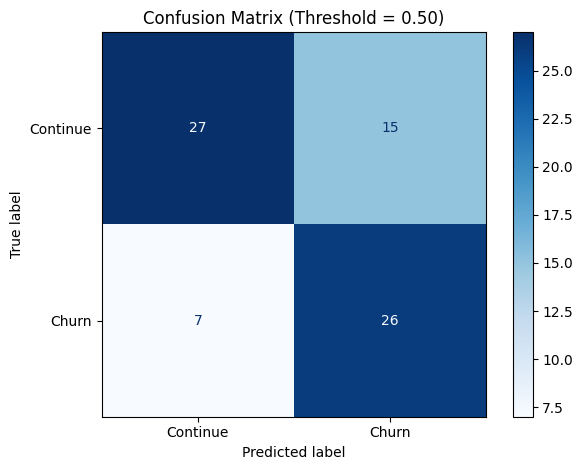

In [14]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(cm,display_labels=["Continue","Churn"]); disp.plot(cmap="Blues",values_format="d")
plt.title("Confusion Matrix (Threshold = 0.50)"); plt.grid(False); plt.tight_layout(); plt.show()

In [15]:
print(classification_report(y_test,y_pred,target_names=["Continue","Churn"],digits=3))

              precision    recall  f1-score   support

    Continue      0.794     0.643     0.711        42
       Churn      0.634     0.788     0.703        33

    accuracy                          0.707        75
   macro avg      0.714     0.715     0.707        75
weighted avg      0.724     0.707     0.707        75



### Confusion Matrix / 混同行列
TP = predicted churn and actually churned. FN = predicted continue but actually churned. In churn analysis, recall is often important because false negatives are customers the model failed to flag.

解約分析では、実際に解約する顧客を見逃すFalse Negativeに注意します。そのため正解率だけでなく、解約クラスの再現率も確認します。

## 14. ROC Curve and AUC / ROC曲線とAUC

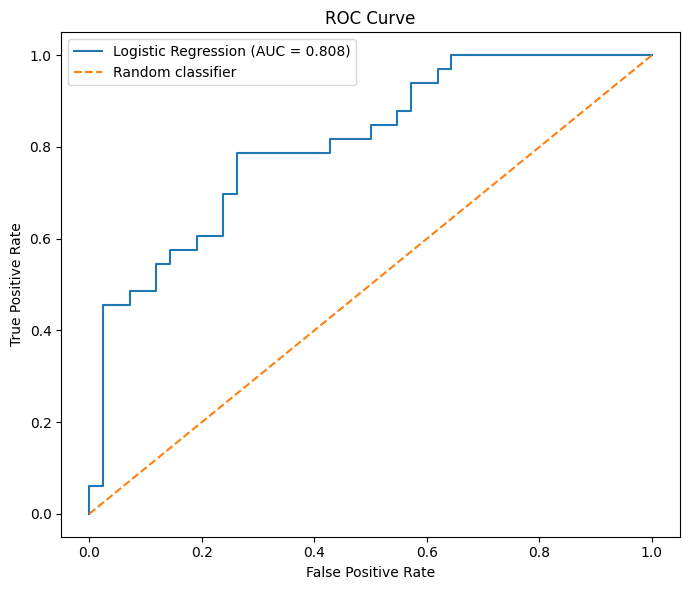

In [16]:
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
plt.figure(figsize=(7,6)); plt.plot(fpr,tpr,label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0,1],[0,1],linestyle="--",label="Random classifier")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curve"); plt.legend(); plt.tight_layout(); plt.show()

## 15. Classification Threshold / 分類閾値
The default 0.50 threshold is not universal. Lower thresholds usually increase churn recall but also increase false positives.

0.50は絶対的な閾値ではありません。閾値を下げると解約顧客を拾いやすくなる一方、False Positiveも増えます。

In [17]:
for threshold in [.30,.50,.70]:
    pred=(y_prob>=threshold).astype(int); tn,fp,fn,tp=confusion_matrix(y_test,pred).ravel()
    recall=tp/(tp+fn); precision=tp/(tp+fp) if tp+fp else 0
    print(f"Threshold={threshold:.2f} | TP={tp} FP={fp} TN={tn} FN={fn} | Precision={precision:.3f} Recall={recall:.3f}")

Threshold=0.30 | TP=30 FP=24 TN=18 FN=3 | Precision=0.556 Recall=0.909
Threshold=0.50 | TP=26 FP=15 TN=27 FN=7 | Precision=0.634 Recall=0.788
Threshold=0.70 | TP=17 FP=5 TN=37 FN=16 | Precision=0.773 Recall=0.515


## 16. Cross-Validation / 交差検証

In [18]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(model,X,y,cv=cv,scoring="roc_auc")
print("ROC-AUC scores:",np.round(scores,3)); print(f"Mean ROC-AUC: {scores.mean():.3f}"); print(f"SD: {scores.std():.3f}")

ROC-AUC scores: [0.777 0.764 0.83  0.735 0.86 ]
Mean ROC-AUC: 0.793
SD: 0.045


## 17. Interpret Coefficients with Odds Ratios / オッズ比による解釈
For interpretation, a second model is fitted with `statsmodels`. Odds ratio > 1 indicates increasing churn odds; odds ratio < 1 indicates decreasing churn odds.

解釈用に`statsmodels`でもモデルを推定します。オッズ比が1より大きければ解約オッズを高める方向、1より小さければ下げる方向です。

In [19]:
stats_df=pd.get_dummies(df[numeric+categorical],columns=categorical,drop_first=True,dtype=float)
X_stats=sm.add_constant(stats_df.astype(float))
stats_model=sm.Logit(df["churn"],X_stats).fit(disp=False)
stats_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  churn   No. Observations:                  300
Model:                          Logit   Df Residuals:                      290
Method:                           MLE   Df Model:                            9
Date:                Sat, 08 Aug 2026   Pseudo R-squ.:                  0.2517
Time:                        18:26:23   Log-Likelihood:                -153.99
converged:                       True   LL-Null:                       -205.78
Covariance Type:            nonrobust   LLR p-value:                 2.974e-18
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2.0919      0.870      2.405      0.016       0.387       3.797
tenure_months             -0.0463      0.008     -5.860      0.000      -0.062      -0.031
monthly_charge             0.0172      0.006      2.698      0.007       0.005       0.030
support_tickets            0.3582      0.121      2.953      0.003       0.120       0.596
login_frequency           -0.0518      0.025     -2.100      0.036      -0.100      -0.003
days_since_last_login      0.0563      0.019      2.988      0.003       0.019       0.093
satisfaction_score        -0.6401      0.154     -4.148      0.000      -0.943      -0.338
auto_payment              -0.9979      0.294     -3.390      0.001      -1.575      -0.421
contract_type_Monthly      0.7794      0.326      2.394      0.017       0.141       1.417
contract_type_Two_Year    -0.6129      0.449     -1.366      0.172      -1.492       0.266
==========================================================================================
"""

In [20]:
odds=pd.DataFrame({"coefficient":stats_model.params,"odds_ratio":np.exp(stats_model.params),"p_value":stats_model.pvalues}).round(4)
odds

,coefficient,odds_ratio,p_value
const,2.0919,8.1001,0.0162
tenure_months,-0.0463,0.9547,0.0000
monthly_charge,0.0172,1.0174,0.0070
support_tickets,0.3582,1.4307,0.0031
login_frequency,-0.0518,0.9495,0.0357
days_since_last_login,0.0563,1.0579,0.0028
satisfaction_score,-0.6401,0.5272,0.0000
auto_payment,-0.9979,0.3687,0.0007
contract_type_Monthly,0.7794,2.1802,0.0167
contract_type_Two_Year,-0.6129,0.5418,0.1718


### Association Is Not Causation / 関連は因果を意味しない
A significant association does not by itself prove causation. For example, more support tickets may reflect underlying service problems rather than support itself causing churn.

統計的な関連があっても因果関係が証明されたわけではありません。問い合わせ回数の多さは、背後にあるサービス上の問題を反映している可能性があります。

## 18. Predict New Customers / 新規顧客の予測

In [21]:
new=pd.DataFrame([
{"tenure_months":4,"monthly_charge":105.0,"support_tickets":4,"login_frequency":5.0,"days_since_last_login":24.0,"satisfaction_score":2,"auto_payment":0,"contract_type":"Monthly"},
{"tenure_months":38,"monthly_charge":68.0,"support_tickets":1,"login_frequency":16.0,"days_since_last_login":3.0,"satisfaction_score":4,"auto_payment":1,"contract_type":"Annual"},
{"tenure_months":65,"monthly_charge":59.0,"support_tickets":0,"login_frequency":18.0,"days_since_last_login":2.0,"satisfaction_score":5,"auto_payment":1,"contract_type":"Two_Year"}])
new_prob=model.predict_proba(new)[:,1]; out=new.copy(); out["churn_probability"]=new_prob; out["prediction_at_0.50"]=(new_prob>=.5).astype(int)
out.round(3)

,tenure_months,monthly_charge,support_tickets,login_frequency,days_since_last_login,satisfaction_score,auto_payment,contract_type,churn_probability,prediction_at_0.50
0,4,105.0,4,5.0,24.0,2,0,Monthly,0.997,1
1,38,68.0,1,16.0,3.0,4,1,Annual,0.100,0
2,65,59.0,0,18.0,2.0,5,1,Two_Year,0.004,0


## 19. Assumptions and Limitations / 前提条件と限界
- Binary outcome for binary logistic regression
- Independent observations
- Linear relationship between continuous predictors and log-odds
- Avoid severe multicollinearity
- Check predictive performance on unseen data
- Simulated educational dataset

- 目的変数が2値であること
- 観測値が独立していること
- 連続説明変数と対数オッズの線形関係
- 強い多重共線性への注意
- 未知データでの性能評価
- 今回は学習用シミュレーションデータ

## 20. Conclusion / まとめ
This Notebook estimated customer churn probability with logistic regression, evaluated classification performance, explored threshold trade-offs, and interpreted odds ratios.

このNotebookでは、顧客の解約確率を推定し、分類性能、閾値によるトレードオフ、オッズ比による係数解釈まで確認しました。

Unlike classical LDA in Chapter 05, logistic regression directly models the probability of a binary outcome and does not require the same multivariate-normality and equal-covariance assumptions.

05の古典的なLDAとは異なり、ロジスティック回帰は2値結果の確率を直接モデル化し、LDAと同じ多変量正規性・等共分散の仮定を必要としません。